In [1]:
!pip install numpy pandas pillow matplotlib wordcloud scipy scikit-learn umap-learn plotly

In [2]:
from os import path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

from scipy.sparse import hstack, csr_matrix

# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader, TensorDataset

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import Lasso, LassoCV, RidgeCV, ElasticNetCV, LogisticRegressionCV

from sklearn.metrics import mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import normalize
from sklearn.preprocessing import MaxAbsScaler


from sklearn.cluster import KMeans, HDBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA, TruncatedSVD, NMF
from umap import UMAP


from sklearn.metrics.pairwise import cosine_similarity

from collections import Counter



import plotly.graph_objects as go
import seaborn as sns

In [3]:
df = pd.read_csv("../../data/processed/glassdoor_reviews_cleaned.csv")


cols = ['summary', 'advice_to_management', 'review_pros','review_cons']
df[cols] = df[cols].fillna("")


In [4]:
df[cols].head(20)

,summary,advice_to_management,review_pros,review_cons
0,IT is Out of Control,Humble yourselves. Remember when you were comi...,"Salary was good for the position, but only bec...",Relentless pressure from the top. Constantly c...
1,Great Company to work with,Bring this great Company at par with similar g...,Great brand name. Top Management are consisten...,Work hours do not adhere to internationally ac...
2,Great,Good,Good and best and bestest best,Not bad and not bad and not bad
3,Vodafone is an Egotistical Company that only c...,You have some amazing staff members who are to...,Unfortunately there were no pros during my tim...,Retail stores are severely understaffed. The n...
4,"Great company, poor processes, high expectations",Handle customer escalations so BAMs can focus ...,Working with business owners or employees to s...,Sales expectations are unrealistic. Due to Cov...
5,Commercial Product Internship,,Very inclusive and helpful environment which m...,
6,Failing Product & Failing Management,,Decent work-life balance. Opportunity for lear...,Growth within the company is based on favoriti...
7,Regrettable Experience - A Workplace To Be War...,,Eye-opening: Teaches you exactly how a company...,Communication breakdown: An endemic lack of co...
8,HR is a joke,Get it together.,Most employees are great. Management will ask ...,HR and upper management do not support employe...
9,Worst company,,Although they are sweet initially at the time ...,No job security. Management shouts at employee...


Initial steps of comments EDA: drawing word cloud. 

Additional stopwords were introduced since those words don't imply any useful information.


"In the preliminary phase of the Exploratory Data Analysis (EDA), a word cloud was generated to visualize the most prominent terms within the comment dataset. To ensure the visualization reflected meaningful semantic patterns, the initial stopword list was expanded to exclude high-frequency terms that lacked domain-specific informational value."

Option 2: Methodology-Focused (Technical & Precise)
"To identify latent themes in the user-generated content, we conducted a frequency-based lexical analysis via word cloud visualization. An augmented stopword filter was applied during the preprocessing stage; this involved removing non-informative tokens and generic discourse markers that would otherwise obscure the substantive content of the corpus."

Option 3: Concise (Best for Short Reports)
"Preliminary EDA involved visualizing term distribution through word clouds. The preprocessing pipeline included an optimized stopword removal process, where the standard lexicon was supplemented with context-specific uninformative terms to improve the signal-to-noise ratio of the visualization."

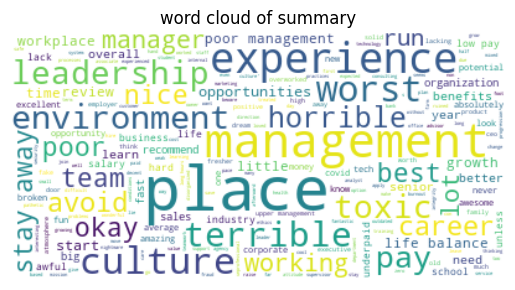

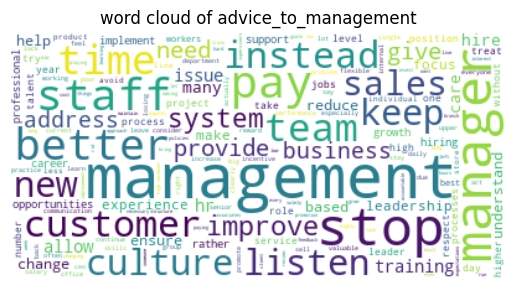

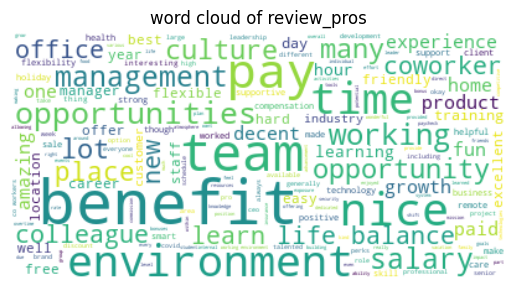

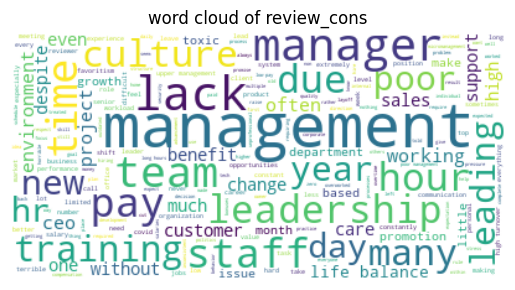

In [5]:
stopwords = STOPWORDS.union(set(["bad","good", "great", "will", "company", "job", "work", "employee", "here",
                                 "people", "employees"
                                 ]))



def plotWordCloudFromDF(df, column):
    text = ' '.join(df[column].astype(str).tolist()).lower()
    wordcloud = WordCloud(max_font_size=50, max_words=300, background_color="white", stopwords=stopwords).generate(text)
    plt.figure()
    plt.title(f"word cloud of {column}")
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()

for col in ['summary', 'advice_to_management', 'review_pros','review_cons']:
    plotWordCloudFromDF(df, col)
    



In [6]:
### THIS IS JUST A DEMO;  NOT PART OF PROJECT
vectorizer = TfidfVectorizer(
    sublinear_tf=True, max_df=0.5, min_df=5, stop_words="english"
)

Xdata = vectorizer.fit_transform(df[cols[0]])
Xdata


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1627 stored elements and shape (1000, 100)>

This step focus on how to choose optimal 

summary original words:  1280 stopword and lowfreq removed:  91


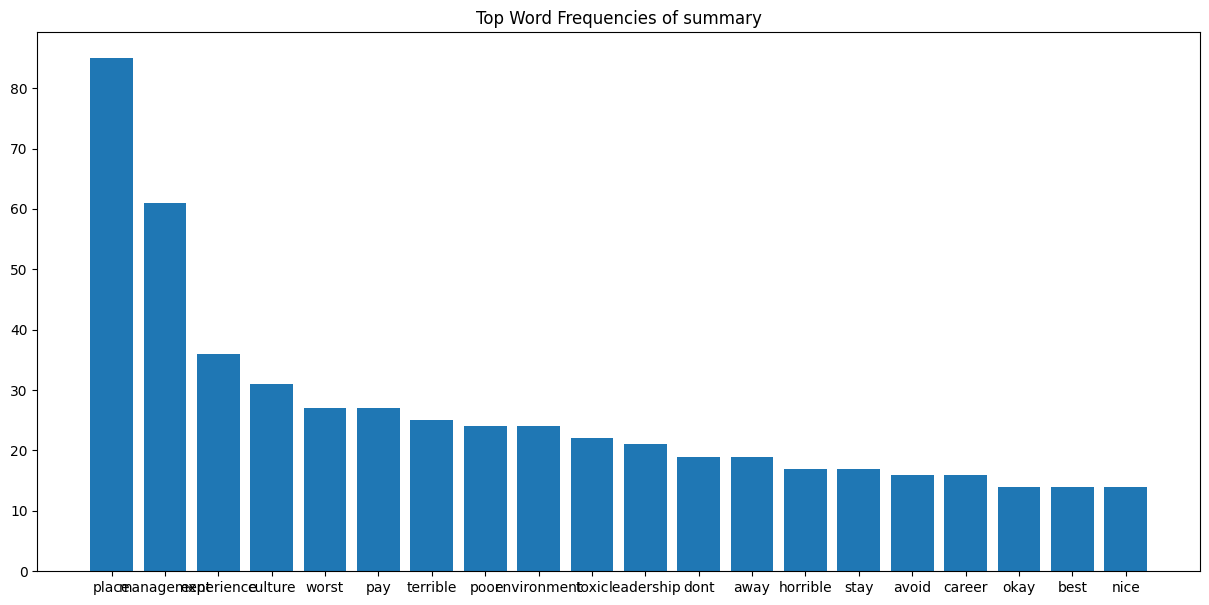

advice_to_management original words:  1650 stopword and lowfreq removed:  117


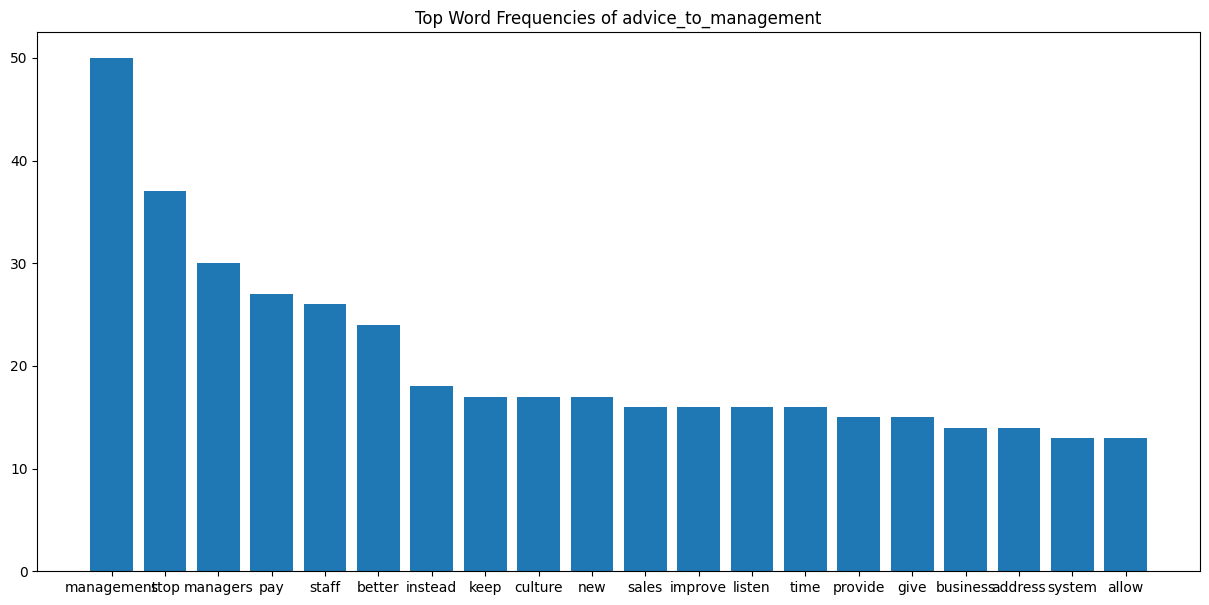

review_pros original words:  2659 stopword and lowfreq removed:  343


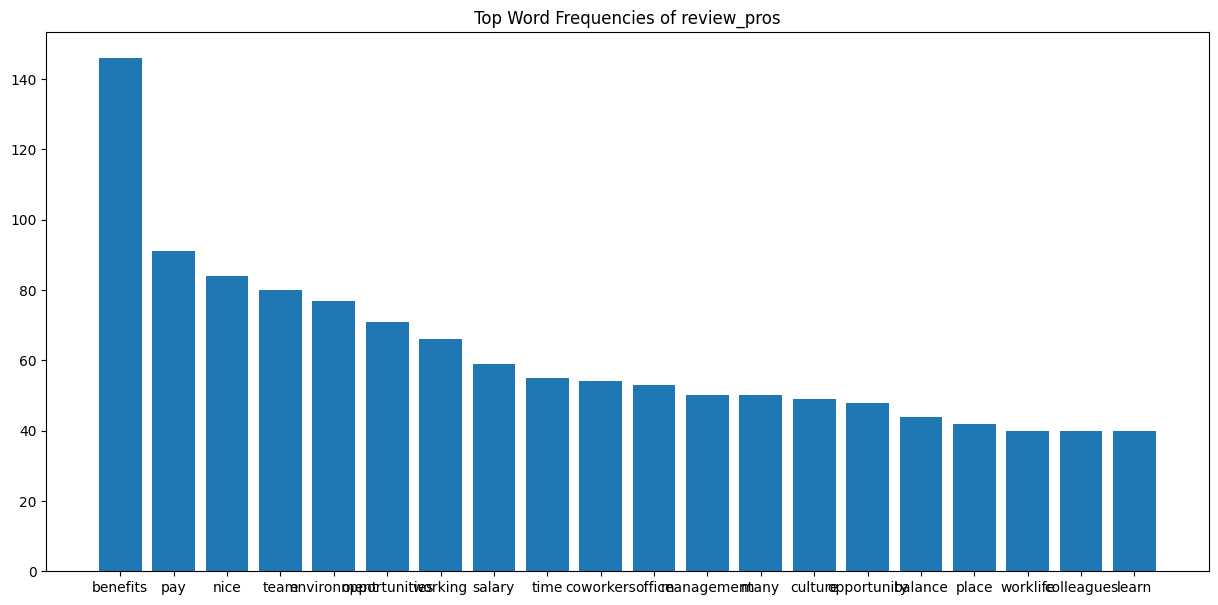

review_cons original words:  5545 stopword and lowfreq removed:  983


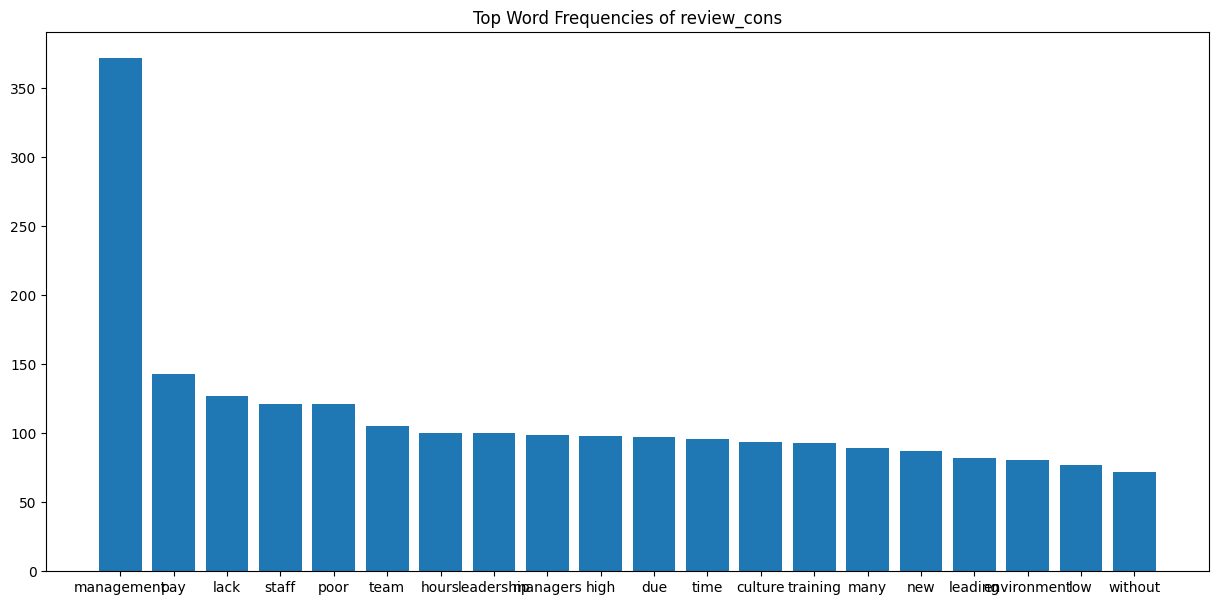

In [7]:

def clean_words(col):
    text = (' '.join(df[col].astype(str).tolist()).lower()
    .replace(",","").replace(".","").replace("!","")
    .replace("(","").replace(")","")
    .replace("'","").replace("\"","")
    .replace("-","").replace("=","")
    .replace(";","").replace("+","")
    .replace(":","").replace("?","")

    )
    # Tokenize and count
    counts = Counter(text.split())
    # Get top 10 most common
    wa = len(counts)
    for i in counts.copy():
        if i in stopwords or  counts[i] < 5:
            counts.pop(i)
    wb = len(counts)
    print(col, "original words: ", wa,  "stopword and lowfreq removed: ", wb)
    top_words = dict(counts.most_common(20))


    plt.figure(figsize=(15, 7))
    plt.bar(top_words.keys(), top_words.values())
    plt.title(f"Top Word Frequencies of {col}")
    plt.show()

    wordfreq = pd.DataFrame(counts, index = [0]).transpose().sort_values(by = [0], ascending = False)
    return wordfreq


for col in cols:
    clean_words(col)


In [8]:

# ---------------------------------------------------------
# 1. Data Preparation (Your exact code, mathematically patched)
# ---------------------------------------------------------
cols = ['summary', 'advice_to_management', 'review_pros', 'review_cons']

# CRITICAL FIX: Added min_df=5 and max_df=0.85 to filter out the noise tail 
# and meaningless corporate stop words (e.g., "company", "work").
vectorizers = [TfidfVectorizer(max_features = 200, 
                               stop_words='english',
                               ngram_range=(1, 3),
                               min_df=5, 
                               max_df=0.8),
                TfidfVectorizer(max_features=200, 
                               stop_words='english',
                               ngram_range=(1, 3),
                               min_df=5, 
                               max_df=0.8),
                TfidfVectorizer(max_features=300, 
                               stop_words='english',
                               ngram_range=(1, 3),
                               min_df=5, 
                               max_df=0.8),
                TfidfVectorizer(max_features=400, 
                               stop_words='english',
                               ngram_range=(1, 4),
                               min_df=5, 
                               max_df=0.8)
               ]
sparse_matrices = []
all_feature_names = []

for col, vec in zip(cols, vectorizers):
    text_data = df[col].fillna('').astype(str)
    sparse_matrices.append(vec.fit_transform(text_data))
    
    vocab = vec.get_feature_names_out()
    prefixed_vocab = [f"{col}__{word}" for word in vocab]
    all_feature_names.extend(prefixed_vocab)

X_Num = df[['count_helpful', 'count_unhelpful', 'covid_related_review', 'flags_business_outlook', 'flags_ceo_approval',
       'flags_recommend_frend', 'rating_culture_values',
       'rating_diversity_inclusion', 'rating_overall', 'rating_work_life',
       'rating_compensation_benefits', 'rating_senior_leadership',
       'rating_career_opportunities',
       'helpfulness_score']]
EncodeCols = ['covid_related_review', 'flags_business_outlook', 'flags_ceo_approval',
       'flags_recommend_frend', 'rating_culture_values',
       'rating_diversity_inclusion', 'rating_overall', 'rating_work_life',
       'rating_compensation_benefits', 'rating_senior_leadership',
       'rating_career_opportunities'    
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), EncodeCols)
    ],
    remainder='passthrough' 
)

X_wordonly = hstack(sparse_matrices)
word_feature_names = np.array(all_feature_names)

sparse_matrices.append(preprocessor.fit_transform(X_Num))
all_feature_names.extend(preprocessor.get_feature_names_out())
all_feature_names = np.array(all_feature_names) 


X_combined = hstack(sparse_matrices)
# df['flags_recommend_frend'] = df['flags_recommend_frend'].map({'POSITIVE':True, "NEGATIVE":False})
y = df[['employee_length', 'employee_job_quit']].values

X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)

yl_train, yl_test = y_train.transpose()[0], y_test.transpose()[0]
yq_train, yq_test = y_train.transpose()[1].astype(int), y_test.transpose()[1].astype(int)
# yr_train, yr_test = y_train.transpose()[2].astype(int), y_test.transpose()[2].astype(int)


print(f"--- Data Structural Audit ---")
print(f"Total Combined Features: {X_combined.shape[1]}") 
print(f"Total Samples: {X_combined.shape[0]}")
print(f"First 30 Feature Names (Sample): {all_feature_names[:30]}")
# print(f"Middle Feature Names (Sample): {all_feature_names[300:310]}")


# Optional: Transform your entire dataset into the 15 Super Themes for predictive modeling
# X_super_themes = np.dot(W_train, kmeans.cluster_centers_.T) # Shape: (n_samples, 15)


scaler = MaxAbsScaler() 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


--- Data Structural Audit ---
Total Combined Features: 992
Total Samples: 1000
First 30 Feature Names (Sample): ['summary__absolutely' 'summary__amazing' 'summary__atmosphere'
 'summary__average' 'summary__avoid' 'summary__away' 'summary__awesome'
 'summary__awful' 'summary__bad' 'summary__bad place' 'summary__balance'
 'summary__benefits' 'summary__best' 'summary__better' 'summary__big'
 'summary__broken' 'summary__business' 'summary__career' 'summary__ceo'
 'summary__company' 'summary__company culture' 'summary__company work'
 'summary__corporate' 'summary__covid' 'summary__culture' 'summary__don'
 'summary__employee' 'summary__employees' 'summary__environment'
 'summary__excellent']


In [9]:
y

array([[20, True],
       [6, False],
       [2, True],
       ...,
       [6, True],
       [1, True],
       [1, True]], dtype=object)

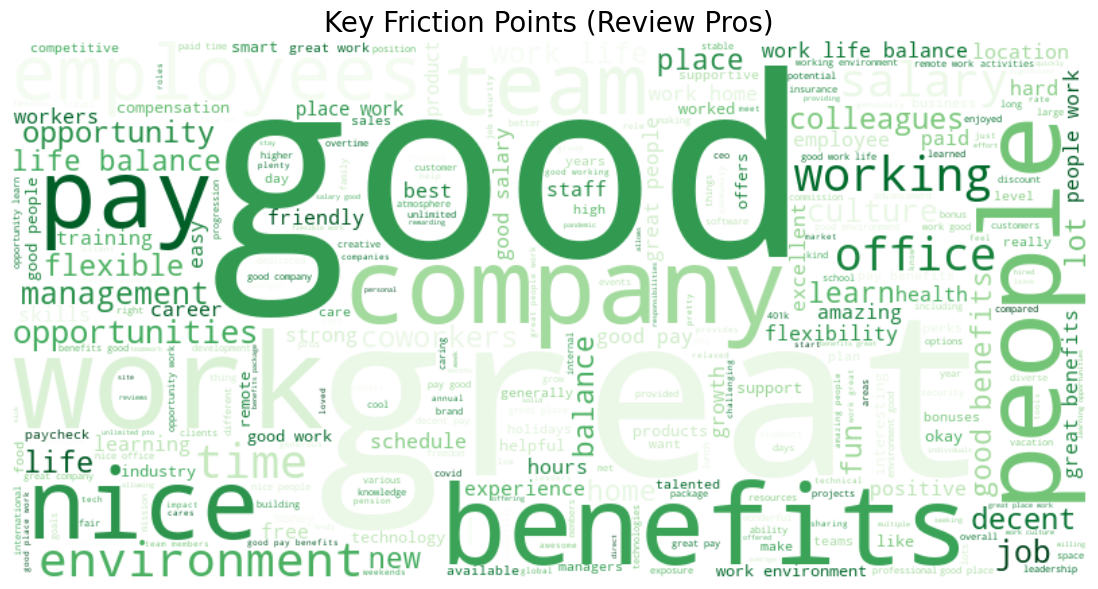

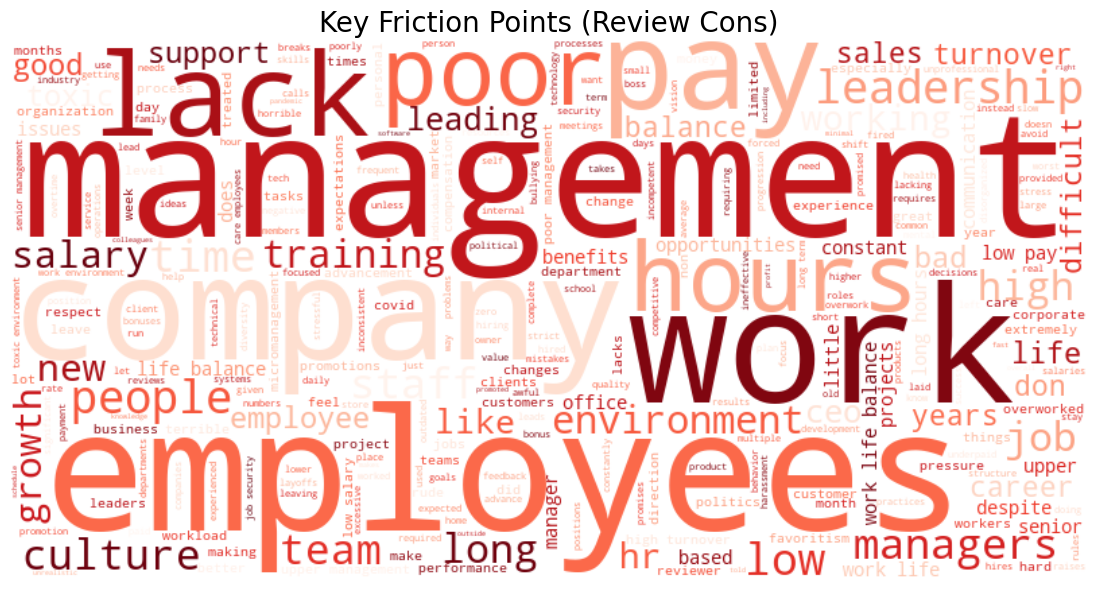

In [10]:


def get_column_word_weights(vectorizer, sparse_mat, prefix):
    feature_names = vectorizer.get_feature_names_out()
    col_indices = [i for i, name in enumerate(feature_names)]
    weights = sparse_mat.mean(axis=0).A1
    
    return {feature_names[i]: weights[i] for i in range(len(feature_names))}


pros_weights = get_column_word_weights(vectorizers[2], sparse_matrices[2], 'review_pros')

wc_pros = WordCloud(
    width=800, height=400, 
    background_color='white',
    colormap='Greens', 
    max_words=300
).generate_from_frequencies(pros_weights)

plt.figure(figsize=(15, 7))
plt.imshow(wc_pros, interpolation='bilinear')
plt.axis('off')
plt.title("Key Friction Points (Review Pros)", fontsize=20)
plt.show()


cons_weights = get_column_word_weights(vectorizers[3], sparse_matrices[3], 'review_cons')

wc_cons = WordCloud(
    width=800, height=400, 
    background_color='white',
    colormap='Reds', 
    max_words=300
).generate_from_frequencies(cons_weights)

plt.figure(figsize=(15, 7))
plt.imshow(wc_cons, interpolation='bilinear')
plt.axis('off')
plt.title("Key Friction Points (Review Cons)", fontsize=20)
plt.show()

In [11]:
# ---------------------------------------------------------
# 2. Model A: Cross-Validated Lasso (scikit-learn)
# ---------------------------------------------------------
print("Training LassoCV...")
lasso_cv_model = LassoCV(cv=10, random_state=42, n_jobs=-1, max_iter=100000)
lasso_cv_model.fit(X_train_scaled, yl_train)

lasso_preds = lasso_cv_model.predict(X_test_scaled)
print(f"LassoCV MSE: {mean_squared_error(yl_test, lasso_preds):.4f}")
print(f"Best Alpha found: {lasso_cv_model.alpha_:.4f}")

non_zero_count = np.sum(lasso_cv_model.coef_ != 0)
print(f"Nonzero-coeff {non_zero_count} / {X_train.shape[1]}")

coefs = lasso_cv_model.coef_

non_zero_indices = np.where(coefs != 0)[0]

impactful_features = pd.DataFrame({
    'Feature': all_feature_names[non_zero_indices],
    'Coefficient': coefs[non_zero_indices]
})

impactful_features['Abs_Coefficient'] = impactful_features['Coefficient'].abs()
impactful_features = impactful_features.sort_values(by='Abs_Coefficient', ascending=False)

print("\n--- Lasso Selected Factors ---")
print(impactful_features[['Feature', 'Coefficient']])

Training LassoCV...
LassoCV MSE: 12.6613
Best Alpha found: 0.0502
Nonzero-coeff 23 / 992

--- Lasso Selected Factors ---
                                Feature   Coefficient
20      cat__rating_senior_leadership_5 -9.937465e-01
19      cat__rating_senior_leadership_3 -7.068179e-01
21   cat__rating_career_opportunities_3 -6.414487e-01
22   cat__rating_career_opportunities_4  5.556888e-01
12                cat__rating_overall_1 -4.935867e-01
16              cat__rating_work_life_4  4.479573e-01
11  cat__rating_diversity_inclusion_4.0  4.289330e-01
15              cat__rating_work_life_3 -3.785853e-01
10  cat__rating_diversity_inclusion_3.0  3.535187e-01
9   cat__rating_diversity_inclusion_1.0 -3.525850e-01
3    cat__flags_ceo_approval_DISAPPROVE  3.256213e-01
6          cat__rating_culture_values_1 -2.422813e-01
17  cat__rating_compensation_benefits_1 -2.359240e-01
8          cat__rating_culture_values_4  1.700138e-01
14                cat__rating_overall_4  1.450288e-01
7          cat_

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:325: RuntimeWarning: divide by zero encountered in matmul
  self.intercept_ = y_offset - X_offset @ self.coef_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:325: RuntimeWarning: overflow encountered in matmul
  self.intercept_ = y_offset - X_offset @ self.coef_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:325: RuntimeWarning: invalid value encountered in matmul
  self.intercept_ = y_offset - X_offset @ self.coef_


In [12]:
non_zero_indices


array([ 19, 940, 941, 946, 949, 950, 951, 953, 954, 956, 959, 961, 964,
       966, 967, 971, 972, 974, 979, 981, 983, 986, 987])

In [13]:
ridge_cv = RidgeCV(cv=10)
ridge_cv.fit(X_train_scaled, yl_train)


ridge_preds = ridge_cv.predict(X_test_scaled)
print(f"RidgeCV MSE: {mean_squared_error(yl_test, ridge_preds):.4f}")
print(f"Best Alpha found: {ridge_cv.alpha_:.4f}")



non_zero_count = np.sum(ridge_cv.coef_ != 0)
print(f"Nonzero-coeff: {non_zero_count} / {X_train.shape[1]}")

coefs = ridge_cv.coef_

non_zero_indices = np.where(coefs != 0)[0]

impactful_features = pd.DataFrame({
    'Feature': all_feature_names[non_zero_indices],
    'Coefficient': coefs[non_zero_indices]
})

impactful_features['Abs_Coefficient'] = impactful_features['Coefficient'].abs()
impactful_features = impactful_features.sort_values(by='Abs_Coefficient', ascending=False)

print("\n--- Ridge Selected Factors ---")
print(impactful_features[['Feature', 'Coefficient']])

RidgeCV MSE: 13.5266
Best Alpha found: 10.0000
Nonzero-coeff: 992 / 992

--- Ridge Selected Factors ---
                             Feature  Coefficient
160     advice_to_management__growth     1.911990
134        advice_to_management__big     1.612128
215       advice_to_management__sell     1.596466
299             review_pros__diverse     1.519023
78            summary__opportunities     1.509839
..                               ...          ...
786           review_cons__political     0.002278
222       advice_to_management__stop     0.001872
203  advice_to_management__processes     0.001265
471           review_pros__rewarding    -0.000577
328            review_pros__generous    -0.000102

[992 rows x 2 columns]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:325: RuntimeWarning: divide by zero encountered in matmul
  self.intercept_ = y_offset - X_offset @ self.coef_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:325: RuntimeWarning: overflow encountered in matmul
  self.intercept_ = y_offset - X_offset @ self.coef_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:325: RuntimeWarning: invalid value encountered in matmul
  self.intercept_ = y_offset - X_offset @ self.coef_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:325: RuntimeWarning: divide by zero encountered in matmul
  self.intercept_ = y_offset - X_offset @ self.coef_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:325: RuntimeW

In [14]:



elastic_cv = ElasticNetCV(cv=10)
elastic_cv.fit(X_train_scaled, yl_train)


elastic_preds = elastic_cv.predict(X_test_scaled)
print(f"Elastic CV MSE: {mean_squared_error(yl_test, elastic_preds):.4f}")
print(f"Best Alpha found: {elastic_cv.alpha_:.4f}")



non_zero_count = np.sum(elastic_cv.coef_ != 0)
print(f"Nonzero-coeff: {non_zero_count} / {X_train.shape[1]}")

coefs = ridge_cv.coef_

non_zero_indices = np.where(coefs != 0)[0]

impactful_features = pd.DataFrame({
    'Feature': all_feature_names[non_zero_indices],
    'Coefficient': coefs[non_zero_indices]
})

impactful_features['Abs_Coefficient'] = impactful_features['Coefficient'].abs()
impactful_features = impactful_features.sort_values(by='Abs_Coefficient', ascending=False)

print("\n--- Elastic Selected Factors ---")
print(impactful_features[['Feature', 'Coefficient']])


Elastic CV MSE: 12.5600
Best Alpha found: 0.0759
Nonzero-coeff: 37 / 992

--- Elastic Selected Factors ---
                             Feature  Coefficient
160     advice_to_management__growth     1.911990
134        advice_to_management__big     1.612128
215       advice_to_management__sell     1.596466
299             review_pros__diverse     1.519023
78            summary__opportunities     1.509839
..                               ...          ...
786           review_cons__political     0.002278
222       advice_to_management__stop     0.001872
203  advice_to_management__processes     0.001265
471           review_pros__rewarding    -0.000577
328            review_pros__generous    -0.000102

[992 rows x 2 columns]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:325: RuntimeWarning: divide by zero encountered in matmul
  self.intercept_ = y_offset - X_offset @ self.coef_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:325: RuntimeWarning: overflow encountered in matmul
  self.intercept_ = y_offset - X_offset @ self.coef_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:325: RuntimeWarning: invalid value encountered in matmul
  self.intercept_ = y_offset - X_offset @ self.coef_


In [15]:
# ---------------------------------------------------------
# 2. Model A: Cross-Validated Lasso (scikit-learn)
# ---------------------------------------------------------
print("Training logistics...")

logCV = LogisticRegressionCV(cv=10, random_state=42, n_jobs=-1, class_weight='balanced')
logCV.fit(X_train_scaled, yq_train)


log_preds = logCV.predict(X_test_scaled)
print(f"LassoCV MSE: {mean_squared_error(yq_test, log_preds):.4f}")

coefs = logCV.coef_.flatten() 

non_zero_indices = np.where(coefs != 0)[0]

impactful_features = pd.DataFrame({
    'Feature': all_feature_names[non_zero_indices],
    'Coefficient': coefs[non_zero_indices]
})

impactful_features['Abs_Coefficient'] = impactful_features['Coefficient'].abs()
impactful_features = impactful_features.sort_values(by='Abs_Coefficient', ascending=False)

print("\n--- Logistics Selected Factors ---")
print(impactful_features[['Feature', 'Coefficient']])

Training logistics...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details

LassoCV MSE: 0.0850

--- Logistics Selected Factors ---
                          Feature  Coefficient
590            review_cons__covid    -3.987663
526             review_pros__work    -3.813197
106             summary__terrible    -3.357677
198  advice_to_management__people    -3.227121
673      review_cons__incompetent    -2.793119
..                            ...          ...
748             review_cons__need    -0.005837
271      review_pros__challenging     0.005315
965         cat__rating_overall_2     0.002748
277        review_pros__companies    -0.002158
637            review_cons__focus    -0.001563

[992 rows x 2 columns]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:212: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:212: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:212: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


In [16]:
print("Training logistics LassoCV...")

loglassoCV = LogisticRegressionCV(cv=10, random_state=42, n_jobs=-1, penalty='l1',Cs=[0.1, 1, 10, 100, 1000], solver='liblinear', class_weight='balanced')
loglassoCV.fit(X_train_scaled, yq_train)


loglasso_preds = loglassoCV.predict(X_test_scaled)
print(f"LassoCV MSE: {mean_squared_error(yq_test, loglasso_preds):.4f}")

coefs = loglassoCV.coef_.flatten() 

non_zero_indices = np.where(coefs != 0)[0]

impactful_features = pd.DataFrame({
    'Feature': all_feature_names[non_zero_indices],
    'Coefficient': coefs[non_zero_indices]
})

impactful_features['Abs_Coefficient'] = impactful_features['Coefficient'].abs()
impactful_features = impactful_features.sort_values(by='Abs_Coefficient', ascending=False)

print("\n--- Lasso Selected Factors ---")
print(impactful_features[['Feature', 'Coefficient']])

Training logistics LassoCV...
LassoCV MSE: 0.0850

--- Lasso Selected Factors ---
                             Feature  Coefficient
42             review_pros__compared   -16.160041
109         review_cons__incompetent   -15.562044
40               review_pros__better   -14.833423
95                review_cons__covid   -14.515818
136           review_cons__structure   -13.895294
..                               ...          ...
73               review_pros__plenty    -0.157339
24        advice_to_management__like     0.086322
131                review_cons__rude     0.052809
172  cat__rating_senior_leadership_2     0.047545
165          cat__rating_work_life_4     0.033476

[178 rows x 2 columns]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be si

In [17]:
print("Training Logistics Ridge ...")

logridgeCV = LogisticRegressionCV(cv=10, random_state=42, n_jobs=-1, penalty='l2',Cs=[0.1, 1, 10, 100, 1000], class_weight='balanced')
logridgeCV.fit(X_train_scaled, yq_train)


logridge_preds = logridgeCV.predict(X_test_scaled)
print(f"RidgeCV MSE: {mean_squared_error(yq_test, logridge_preds):.4f}")

coefs = logridgeCV.coef_.flatten() 

non_zero_indices = np.where(coefs != 0)[0]

impactful_features = pd.DataFrame({
    'Feature': all_feature_names[non_zero_indices],
    'Coefficient': coefs[non_zero_indices]
})

impactful_features['Abs_Coefficient'] = impactful_features['Coefficient'].abs()
impactful_features = impactful_features.sort_values(by='Abs_Coefficient', ascending=False)

print("\n--- Lasso Selected Factors ---")
print(impactful_features[['Feature', 'Coefficient']])

Training Logistics Ridge ...
RidgeCV MSE: 0.0850

--- Lasso Selected Factors ---
                          Feature  Coefficient
590            review_cons__covid    -5.053419
526             review_pros__work    -5.012895
106             summary__terrible    -4.349527
198  advice_to_management__people    -4.216786
673      review_cons__incompetent    -3.855386
..                            ...          ...
277        review_pros__companies    -0.005706
637            review_cons__focus    -0.002988
613            review_cons__doesn     0.002273
748             review_cons__need    -0.001532
165  advice_to_management__higher     0.001176

[992 rows x 2 columns]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be si

In [18]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 25422 stored elements and shape (800, 992)>

In [19]:
#### STEP 1: matrix decomposition
n_topics = 50 
nmf = NMF(n_components=n_topics, init='nndsvd', random_state=42)

# V \approx W H
W = nmf.fit_transform(X_wordonly)  # comments
H = nmf.components_ # words

n_docs = W.shape[0]
n_micro_topics = H.shape[0]
print(f"Number of comments: {n_docs} | Number of features: {H.shape[1]}")
print(f"Themes of NMF: {n_micro_topics}")


#### STEP 2: clustering the comments
doc_reducer = UMAP(n_components=2, metric='cosine', random_state=42)
doc_embedding = doc_reducer.fit_transform(W) 

doc_clusterer = HDBSCAN(min_cluster_size=20)
doc_labels = doc_clusterer.fit_predict(doc_embedding)

n_doc_clusters = len(set(doc_labels)) - (1 if -1 in doc_labels else 0)
n_doc_noise = list(doc_labels).count(-1)
print(f"Number of categories of comments: {n_doc_clusters} ")
print(f"Useless comments: {n_doc_noise} ({(n_doc_noise/n_docs)*100:.2f}%)")


#### STEP 3: clustering the themes
H_norm = normalize(H, norm='l2')
topic_reducer = UMAP(n_components=10, metric='cosine', random_state=42)
topic_embedding = topic_reducer.fit_transform(H_norm)

topic_clusterer = HDBSCAN(min_cluster_size=3)
super_theme_labels = topic_clusterer.fit_predict(topic_embedding)

n_super_themes = len(set(super_theme_labels)) - (1 if -1 in super_theme_labels else 0)
n_topic_noise = list(super_theme_labels).count(-1)

print(f"Number of (Super Themes): {n_super_themes}")
print(f"Noise Themes: {n_topic_noise}")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:615: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:615: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:615: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Number of comments: 1000 | Number of features: 940
Themes of NMF: 50
Number of categories of comments: 21 
Useless comments: 265 (26.50%)
Number of (Super Themes): 7
Noise Themes: 6


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


In [20]:

comparison_df = pd.crosstab(df['company_name'], doc_labels)
comparison_df

col_0,-1,0,1,2,3,4,5,6,7,8,...,11,12,13,14,15,16,17,18,19,20
company_name,,,,,,,,,,,,,,,,,,,,,
1 800 CONTACTS,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1Path,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
360 Degree Cloud Technologies,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
360i,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3D Exhibits,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
easyHotel Ltd,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
iMobile,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
payever,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
companydf = pd.DataFrame({
    "company_name":df['company_name'], 
    "doc_labels": doc_labels
})




In [22]:




company_counts = companydf['company_name'].value_counts()
companydf.sort_values(by = "doc_labels").to_csv("2.csv")

keep_companies = company_counts[company_counts >= 10].index
filtered_df = companydf[(companydf['company_name'].isin(keep_companies)) & (companydf['doc_labels']>-1)].copy()
print(f"Number of company: {len(company_counts)}, after filitered: {len(keep_companies)}")

company_categories = filtered_df.groupby('company_name')['doc_labels'].unique()
company_categories.to_frame().to_csv("1.csv")



Number of company: 693, after filitered: 11


In [23]:

all_nodes = list(filtered_df['company_name'].unique()) + list(filtered_df['doc_labels'].unique())
node_dict = {name: i for i, name in enumerate(all_nodes)}

links = filtered_df.groupby(['company_name', 'doc_labels']).size().reset_index(name='value')
links['source'] = links['company_name'].map(node_dict)
links['target'] = links['doc_labels'].map(node_dict)

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 20,
      thickness = 30,
      line = dict(color = "black", width = 0.5),
      label = all_nodes,
      color = "royalblue"
    ),
    link = dict(
      source = links['source'],
      target = links['target'],
      value = links['value'],
      color = "rgba(173, 216, 230, 0.4)" 
  ))])

fig.update_layout(
    title_text="",
    font_size=12,
    height=700
)

fig.show()

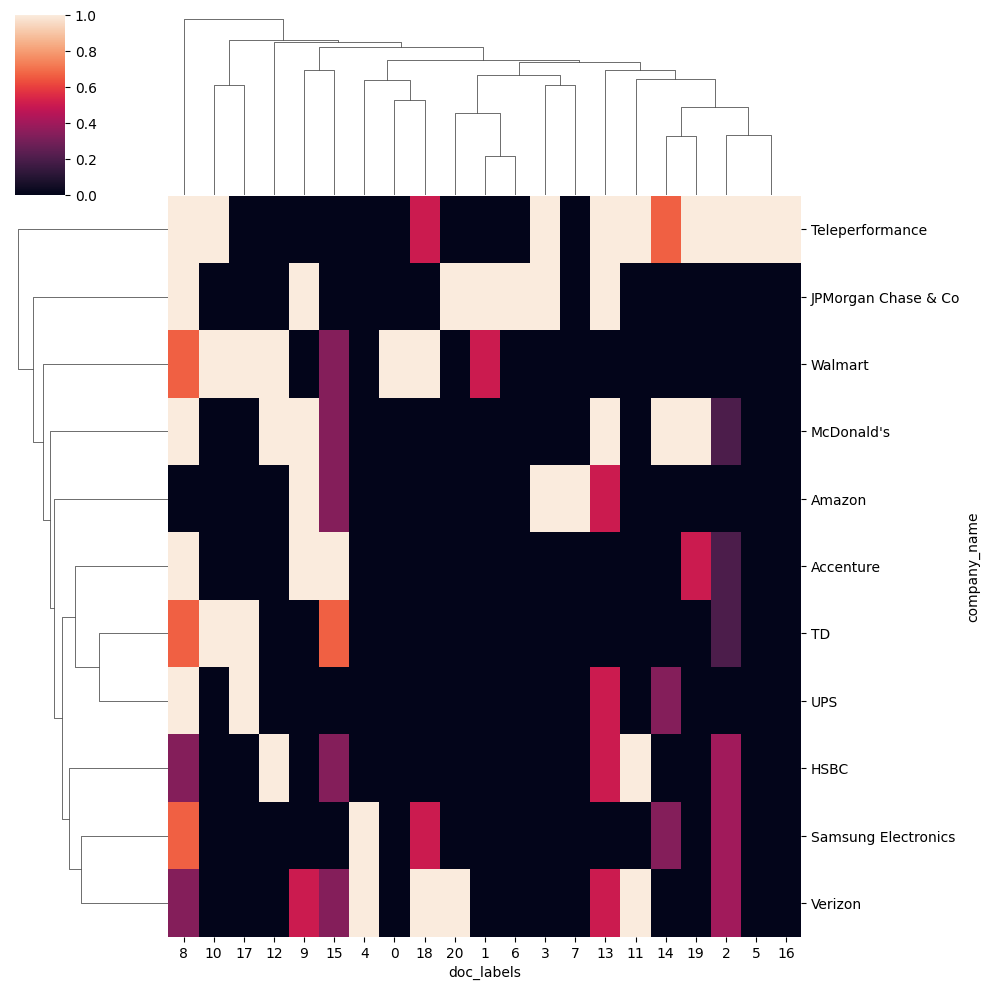

In [24]:

category_counts = filtered_df.groupby(['company_name', 'doc_labels']).size().unstack(fill_value=0)

category_counts
sns.clustermap(category_counts, standard_scale=1)

In [25]:


super_theme_summary = []

for st_id in sorted(list(set(super_theme_labels))):
    if st_id == -1: continue # bypass noise
    
    micro_indices = np.where(super_theme_labels == st_id)[0]
    
    aggregated_weights = np.mean(H[micro_indices], axis=0)
    
    top_indices = aggregated_weights.argsort()[::-1][:8]
    top_words = word_feature_names[top_indices]
    
    super_theme_summary.append({
        "Super Theme ID": st_id,
        "Micro Topic Count": len(micro_indices),
        "Key Words": ", ".join(top_words)
    })

df_themes = pd.DataFrame(super_theme_summary)
print("💎 (Super Themes):")
print(df_themes.to_string(index=False))
print("\n" + "="*50)


if n_doc_clusters > 0:
    largest_cluster = pd.Series(doc_labels[doc_labels != -1]).value_counts().idxmax()
    print(f"🔍 Top Cluster {largest_cluster}):")
    
    cluster_doc_idx = np.where(doc_labels == largest_cluster)[0]
    
    avg_topic_weights = np.mean(W[cluster_doc_idx], axis=0)
    
    top_micro_idx = avg_topic_weights.argmax()
    target_super_theme = super_theme_labels[top_micro_idx]
    
    print(f" - Micro Theme ID: {top_micro_idx}")
    print(f" - Super Theme ID: {target_super_theme}")

💎 (Super Themes):
 Super Theme ID  Micro Topic Count                                                                                                                                                                                             Key Words
              0                  3                      summary__terrible, summary__employees, review_pros__job, advice_to_management__stop, review_cons__terrible, summary__life, review_pros__location, advice_to_management__employee
              1                  6                                                    review_pros__company, review_pros__pay, summary__worst, review_pros__time, review_pros__salary, summary__run, summary__away, review_pros__good pay
              2                  8                                  advice_to_management__management, summary__job, advice_to_management__employees, summary__good, summary__pay, review_cons__hours, review_cons__pay, review_cons__low
              3                  3 review_cons__wo